In [ ]:
# ============================================================
# XLM-RoBERTa Multilingual PII Masking Training
# Dataset: ai4privacy/pii-masking-400k (public)
# Labels: 35 (BIO)
# RTX A1000 6GB SAFE VERSION
# ============================================================

%pip install transformers datasets seqeval accelerate -q

import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from seqeval.metrics import accuracy_score, f1_score


# ------------------------------------------------------------
# 1️⃣ Verify GPU
# ------------------------------------------------------------
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 2️⃣ Load Dataset
# ------------------------------------------------------------
dataset = load_dataset("ai4privacy/pii-masking-400k")
train_data = dataset["train"]
val_data = dataset["validation"]

print("Train size:", len(train_data))
print("Validation size:", len(val_data))


# ------------------------------------------------------------
# 3️⃣ Build Label Mapping
# ------------------------------------------------------------
all_labels = set()
for example in train_data:
    for label in example["mbert_token_classes"]:
        all_labels.add(label)

label_list = sorted(list(all_labels))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

num_labels = len(label_list)
print("Number of labels:", num_labels)


# ------------------------------------------------------------
# 4️⃣ Load XLM-R
# ------------------------------------------------------------
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

# 🔴 Important for memory
model.config.use_cache = False


# ------------------------------------------------------------
# 5️⃣ Encode Data (Memory Safe: max_length=256)
# ------------------------------------------------------------
def encode_example(example):
    encoding = tokenizer(
        example["mbert_tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=256,  # 🔴 Reduced from 512
        padding=False,
    )

    word_ids = encoding.word_ids()
    labels = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        elif word_idx != previous_word_idx:
            label = example["mbert_token_classes"][word_idx]
            labels.append(label2id[label])
        else:
            labels.append(-100)

        previous_word_idx = word_idx

    encoding["labels"] = labels
    return encoding


tokenized_train = train_data.map(
    encode_example,
    remove_columns=train_data.column_names
)

tokenized_val = val_data.map(
    encode_example,
    remove_columns=val_data.column_names
)

data_collator = DataCollatorForTokenClassification(tokenizer)


# ------------------------------------------------------------
# 6️⃣ Metrics
# ------------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_preds = []
    true_labels = []

    for pred_seq, label_seq in zip(preds, labels):
        p_seq, l_seq = [], []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                p_seq.append(id2label[p])
                l_seq.append(id2label[l])
        true_preds.append(p_seq)
        true_labels.append(l_seq)

    return {
        "accuracy": accuracy_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds),
    }


# ------------------------------------------------------------
# 7️⃣ Training Config (6GB SAFE)
# ------------------------------------------------------------
training_args = TrainingArguments(
    output_dir="./models/pii_xlmr",

    learning_rate=3e-5,

    # 🔴 Reduced batch size
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    # 🔴 Accumulate to simulate larger batch
    gradient_accumulation_steps=4,

    num_train_epochs=3,
    weight_decay=0.01,
    warmup_steps=500,

    fp16=torch.cuda.is_available(),

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1,
    logging_steps=200,
    report_to="none",
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


# ------------------------------------------------------------
# 8️⃣ Train
# ------------------------------------------------------------
trainer.train()


# ------------------------------------------------------------
# 9️⃣ Final Evaluation
# ------------------------------------------------------------
metrics = trainer.evaluate()

print("\nFinal Evaluation:")
for k, v in metrics.items():
    print(f"{k}: {v}")


# ------------------------------------------------------------
# 🔟 Save Clean Final Model
# ------------------------------------------------------------
trainer.save_model("./models/pii_xlmr_final")
tokenizer.save_pretrained("./models/pii_xlmr_final")

print("\nTraining complete.")
print("Model saved to ./models/pii_xlmr_final")

Note: you may need to restart the kernel to use updated packages.


c:\Users\andreea.asimine\OneDrive - Siemens Energy\Desktop\UserPrivacy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
GPU: NVIDIA RTX A1000 6GB Laptop GPU
Train size: 325517
Validation size: 81379
Number of labels: 35


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 912.03it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 81379/81379 [00:36<00:00, 2214

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.133627,0.030192,0.989443,0.892990


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.19s/it]


In [14]:
# ============================================================
# XLM-RoBERTa Multilingual PII Masking Training (CONTINUE)
# ============================================================

%pip install transformers datasets seqeval accelerate -q

import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from seqeval.metrics import accuracy_score, f1_score


# ------------------------------------------------------------
# 1️⃣ Verify GPU
# ------------------------------------------------------------
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# 2️⃣ Load Dataset
# ------------------------------------------------------------
dataset = load_dataset("ai4privacy/pii-masking-400k")
train_data = dataset["train"]
val_data = dataset["validation"]

print("Train size:", len(train_data))
print("Validation size:", len(val_data))


# ------------------------------------------------------------
# 3️⃣ Build Label Mapping (same as before)
# ------------------------------------------------------------
all_labels = set()
for example in train_data:
    for label in example["mbert_token_classes"]:
        all_labels.add(label)

label_list = sorted(list(all_labels))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

num_labels = len(label_list)
print("Number of labels:", num_labels)


# ------------------------------------------------------------
# 4️⃣ Load Tokenizer
# ------------------------------------------------------------
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


# ------------------------------------------------------------
# 5️⃣ Load Model FROM CHECKPOINT (IMPORTANT)
# ------------------------------------------------------------
model = AutoModelForTokenClassification.from_pretrained(
    "./models/pii_xlmr/checkpoint-20345"
)

model.config.use_cache = False


# ------------------------------------------------------------
# 6️⃣ Encode Data
# ------------------------------------------------------------
def encode_example(example):
    encoding = tokenizer(
        example["mbert_tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=256,
        padding=False,
    )

    word_ids = encoding.word_ids()
    labels = []
    previous_word_idx = None

    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)
        elif word_idx != previous_word_idx:
            label = example["mbert_token_classes"][word_idx]
            labels.append(label2id[label])
        else:
            labels.append(-100)

        previous_word_idx = word_idx

    encoding["labels"] = labels
    return encoding


tokenized_train = train_data.map(
    encode_example,
    remove_columns=train_data.column_names
)

tokenized_val = val_data.map(
    encode_example,
    remove_columns=val_data.column_names
)

data_collator = DataCollatorForTokenClassification(tokenizer)


# ------------------------------------------------------------
# 7️⃣ Metrics
# ------------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_preds = []
    true_labels = []

    for pred_seq, label_seq in zip(preds, labels):
        p_seq, l_seq = [], []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                p_seq.append(id2label[p])
                l_seq.append(id2label[l])
        true_preds.append(p_seq)
        true_labels.append(l_seq)

    return {
        "accuracy": accuracy_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds),
    }


# ------------------------------------------------------------
# 8️⃣ Training Config (UNCHANGED)
# ------------------------------------------------------------
training_args = TrainingArguments(
    output_dir="./models/pii_xlmr",
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    weight_decay=0.01,
    warmup_steps=500,
    fp16=torch.cuda.is_available(),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    logging_steps=200,
    report_to="none",
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


# ------------------------------------------------------------
# 9️⃣ Continue Training (NO resume_from_checkpoint)
# ------------------------------------------------------------
trainer.train()


# ------------------------------------------------------------
# 🔟 Final Evaluation
# ------------------------------------------------------------
metrics = trainer.evaluate()

print("\nFinal Evaluation:")
for k, v in metrics.items():
    print(f"{k}: {v}")


# ------------------------------------------------------------
# 1️⃣1️⃣ Save Final Model
# ------------------------------------------------------------
trainer.save_model("./models/pii_xlmr_final")
tokenizer.save_pretrained("./models/pii_xlmr_final")

print("\nTraining continued and completed.")

Note: you may need to restart the kernel to use updated packages.
CUDA available: True
GPU: NVIDIA RTX A1000 6GB Laptop GPU
Train size: 325517
Validation size: 81379
Number of labels: 35


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1066.76it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.057449,0.026269,0.991557,0.913198


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.25s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la


Final Evaluation:
eval_loss: 0.026269398629665375
eval_accuracy: 0.9915573762511197
eval_f1: 0.9131978528037515
eval_runtime: 11251.0359
eval_samples_per_second: 7.233
eval_steps_per_second: 1.808
epoch: 1.0


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.59s/it]


Training continued and completed.


In [12]:
import torch
print("CUDA:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))
print("Allocated (GB):", torch.cuda.memory_allocated() / 1e9)

CUDA: True
Device: NVIDIA RTX A1000 6GB Laptop GPU
Allocated (GB): 7.79402496


In [16]:
%pip install matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from seqeval.metrics import f1_score

# Get predictions
predictions = trainer.predict(tokenized_val)
logits = predictions.predictions
labels = predictions.label_ids
preds = np.argmax(logits, axis=-1)

sentence_f1_scores = []

for pred_seq, label_seq in zip(preds, labels):
    p_seq, l_seq = [], []
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            p_seq.append(id2label[p])
            l_seq.append(id2label[l])
    if len(l_seq) > 0:
        score = f1_score([l_seq], [p_seq])
        sentence_f1_scores.append(score)

plt.figure()
plt.boxplot(sentence_f1_scores)
plt.title("Sentence-Level F1 Distribution")
plt.ylabel("F1 Score")
plt.show()

KeyboardInterrupt: 

In [18]:
subset_val = tokenized_val.shuffle(seed=42).select(range(5000))
predictions = trainer.predict(subset_val)

logits = predictions.predictions
labels = predictions.label_ids
preds = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

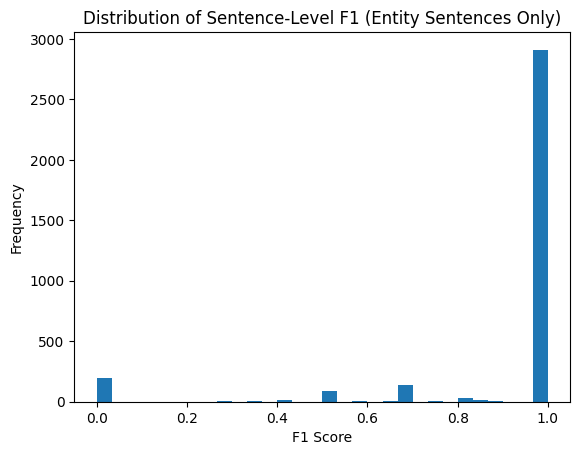

In [22]:
sentence_f1_scores = []

for pred_seq, label_seq in zip(preds, labels):
    p_seq, l_seq = [], []
    contains_entity = False
    
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            l_label = id2label[l]
            p_label = id2label[p]
            
            if l_label != "O":
                contains_entity = True
            
            p_seq.append(p_label)
            l_seq.append(l_label)

    if contains_entity:
        sentence_f1_scores.append(f1_score([l_seq], [p_seq]))

plt.figure()
plt.hist(sentence_f1_scores, bins=30)
plt.title("Distribution of Sentence-Level F1 (Entity Sentences Only)")
plt.xlabel("F1 Score")
plt.ylabel("Frequency")
plt.show()

In [26]:
true_preds = []
true_labels = []

for pred_seq, label_seq in zip(preds, labels):
    p_seq, l_seq = [], []
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            p_seq.append(id2label[p])
            l_seq.append(id2label[l])
    true_preds.append(p_seq)
    true_labels.append(l_seq)

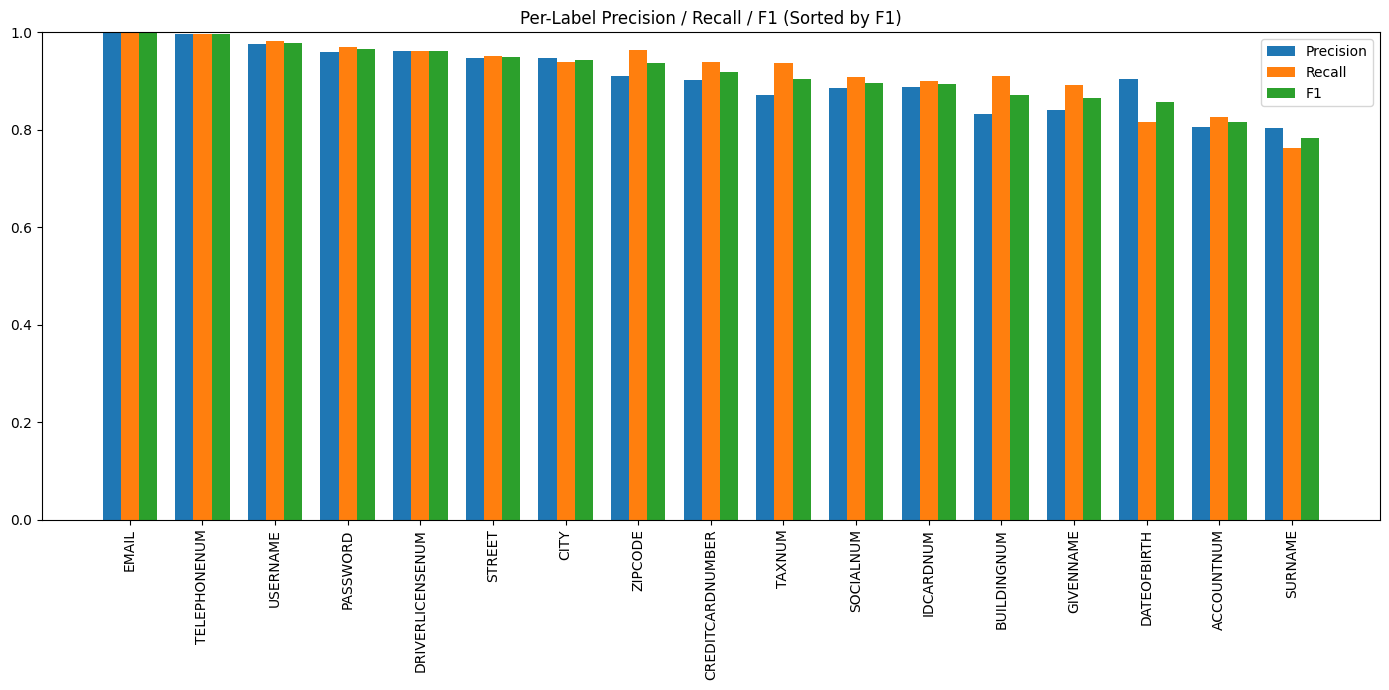

In [27]:
from seqeval.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(true_labels, true_preds, output_dict=True)

metrics_list = []

for label, metrics in report.items():
    if label not in ["micro avg", "macro avg", "weighted avg"]:
        metrics_list.append((
            label,
            metrics["precision"],
            metrics["recall"],
            metrics["f1-score"]
        ))

# Sort by F1 descending
metrics_list = sorted(metrics_list, key=lambda x: x[3], reverse=True)

labels_plot = [x[0] for x in metrics_list]
precision = [x[1] for x in metrics_list]
recall = [x[2] for x in metrics_list]
f1 = [x[3] for x in metrics_list]

x = np.arange(len(labels_plot))

plt.figure(figsize=(14,7))
plt.bar(x - 0.25, precision, width=0.25, label="Precision")
plt.bar(x, recall, width=0.25, label="Recall")
plt.bar(x + 0.25, f1, width=0.25, label="F1")

plt.xticks(x, labels_plot, rotation=90)
plt.ylim(0, 1)
plt.legend()
plt.title("Per-Label Precision / Recall / F1 (Sorted by F1)")
plt.tight_layout()
plt.show()

In [30]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [32]:
all_true = []
all_pred = []

for pred_seq, label_seq in zip(preds, labels):
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            all_true.append(id2label[l])
            all_pred.append(id2label[p])

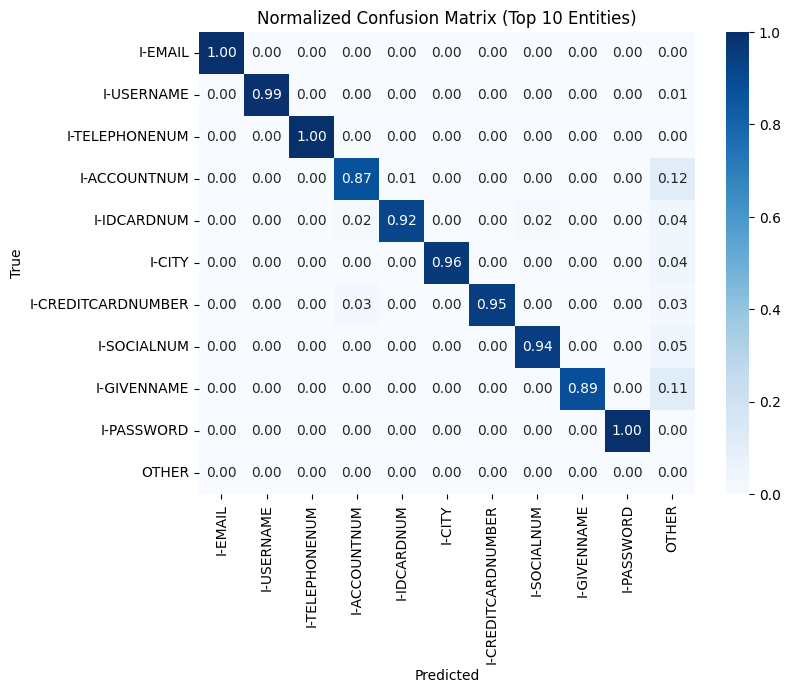

In [33]:
from collections import Counter
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Remove "O"
filtered_true = [t for t in all_true if t != "O"]
filtered_pred = [p for t, p in zip(all_true, all_pred) if t != "O"]

# Top 10 most frequent entity labels
top_labels = [label for label, _ in Counter(filtered_true).most_common(10)]

final_true = []
final_pred = []

for t, p in zip(filtered_true, filtered_pred):
    if t in top_labels:
        final_true.append(t)
        final_pred.append(p if p in top_labels else "OTHER")

labels_plot = top_labels + ["OTHER"]

cm = confusion_matrix(final_true, final_pred, labels=labels_plot, normalize="true")

plt.figure(figsize=(8,6))
sns.heatmap(cm, xticklabels=labels_plot, yticklabels=labels_plot, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix (Top 10 Entities)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [34]:
import pandas as pd
from collections import defaultdict

# Rebuild all_true/all_pred if needed
all_true = []
all_pred = []

for pred_seq, label_seq in zip(preds, labels):
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            all_true.append(id2label[l])
            all_pred.append(id2label[p])

tp = defaultdict(int)
fp = defaultdict(int)
fn = defaultdict(int)
support = defaultdict(int)

for true, pred in zip(all_true, all_pred):
    support[true] += 1
    
    if true == pred:
        tp[true] += 1
    else:
        fp[pred] += 1
        fn[true] += 1

labels_list = sorted(set(all_true))

rows = []

for l in labels_list:
    TP = tp[l]
    FP = fp[l]
    FN = fn[l]
    SUP = support[l]
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fp_rate = FP / (TP + FP) if (TP + FP) > 0 else 0
    fn_rate = FN / (TP + FN) if (TP + FN) > 0 else 0
    
    rows.append([
        l, TP, FP, FN, SUP,
        round(precision, 3),
        round(recall, 3),
        round(f1, 3),
        round(fp_rate, 3),
        round(fn_rate, 3)
    ])

df_errors = pd.DataFrame(
    rows,
    columns=[
        "Label",
        "TP",
        "FP",
        "FN",
        "Support",
        "Precision",
        "Recall",
        "F1",
        "FP Rate",
        "FN Rate"
    ]
)

df_errors = df_errors.sort_values("F1", ascending=False)

df_errors

,Label,TP,FP,FN,Support,Precision,Recall,F1,FP Rate,FN Rate
6,B-EMAIL,498,0,0,498,1.000,1.000,1.000,0.000,0.000
23,I-EMAIL,4480,0,0,4480,1.000,1.000,1.000,0.000,0.000
31,I-TELEPHONENUM,2216,5,4,2220,0.998,0.998,0.998,0.002,0.002
34,O,223676,658,689,224365,0.997,0.997,0.997,0.003,0.003
14,B-TELEPHONENUM,348,1,1,349,0.997,0.997,0.997,0.003,0.003
32,I-USERNAME,2505,13,15,2520,0.995,0.994,0.994,0.005,0.006
26,I-PASSWORD,1096,13,1,1097,0.988,0.999,0.994,0.012,0.001
15,B-USERNAME,524,12,10,534,0.978,0.981,0.979,0.022,0.019
22,I-DRIVERLICENSENUM,1017,24,26,1043,0.977,0.975,0.976,0.023,0.025
9,B-PASSWORD,167,5,4,171,0.971,0.977,0.974,0.029,0.023


In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

binary_true = []
binary_pred = []

for true, pred in zip(all_true, all_pred):
    true_bin = 1 if true != "O" else 0
    pred_bin = 1 if pred != "O" else 0
    
    binary_true.append(true_bin)
    binary_pred.append(pred_bin)

In [41]:
cm = confusion_matrix(binary_true, binary_pred)

tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

TP: 60845
FP: 654
FN: 2384
TN: 234027


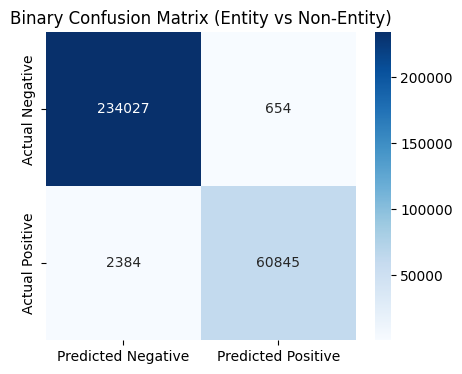

In [42]:
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative", "Actual Positive"]
)

plt.title("Binary Confusion Matrix (Entity vs Non-Entity)")
plt.show()

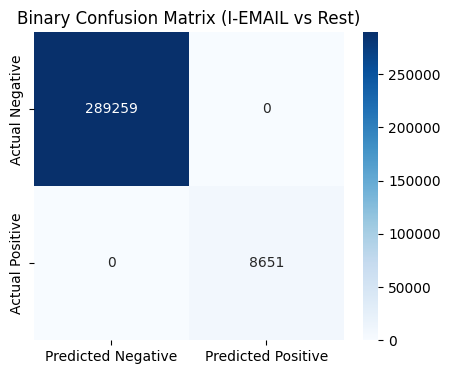

In [43]:
target = "I-EMAIL"

binary_true = []
binary_pred = []

for true, pred in zip(all_true, all_pred):
    true_bin = 1 if true == target else 0
    pred_bin = 1 if pred == target else 0
    
    binary_true.append(true_bin)
    binary_pred.append(pred_bin)

cm = confusion_matrix(binary_true, binary_pred)

tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative", "Actual Positive"]
)

plt.title(f"Binary Confusion Matrix ({target} vs Rest)")
plt.show()

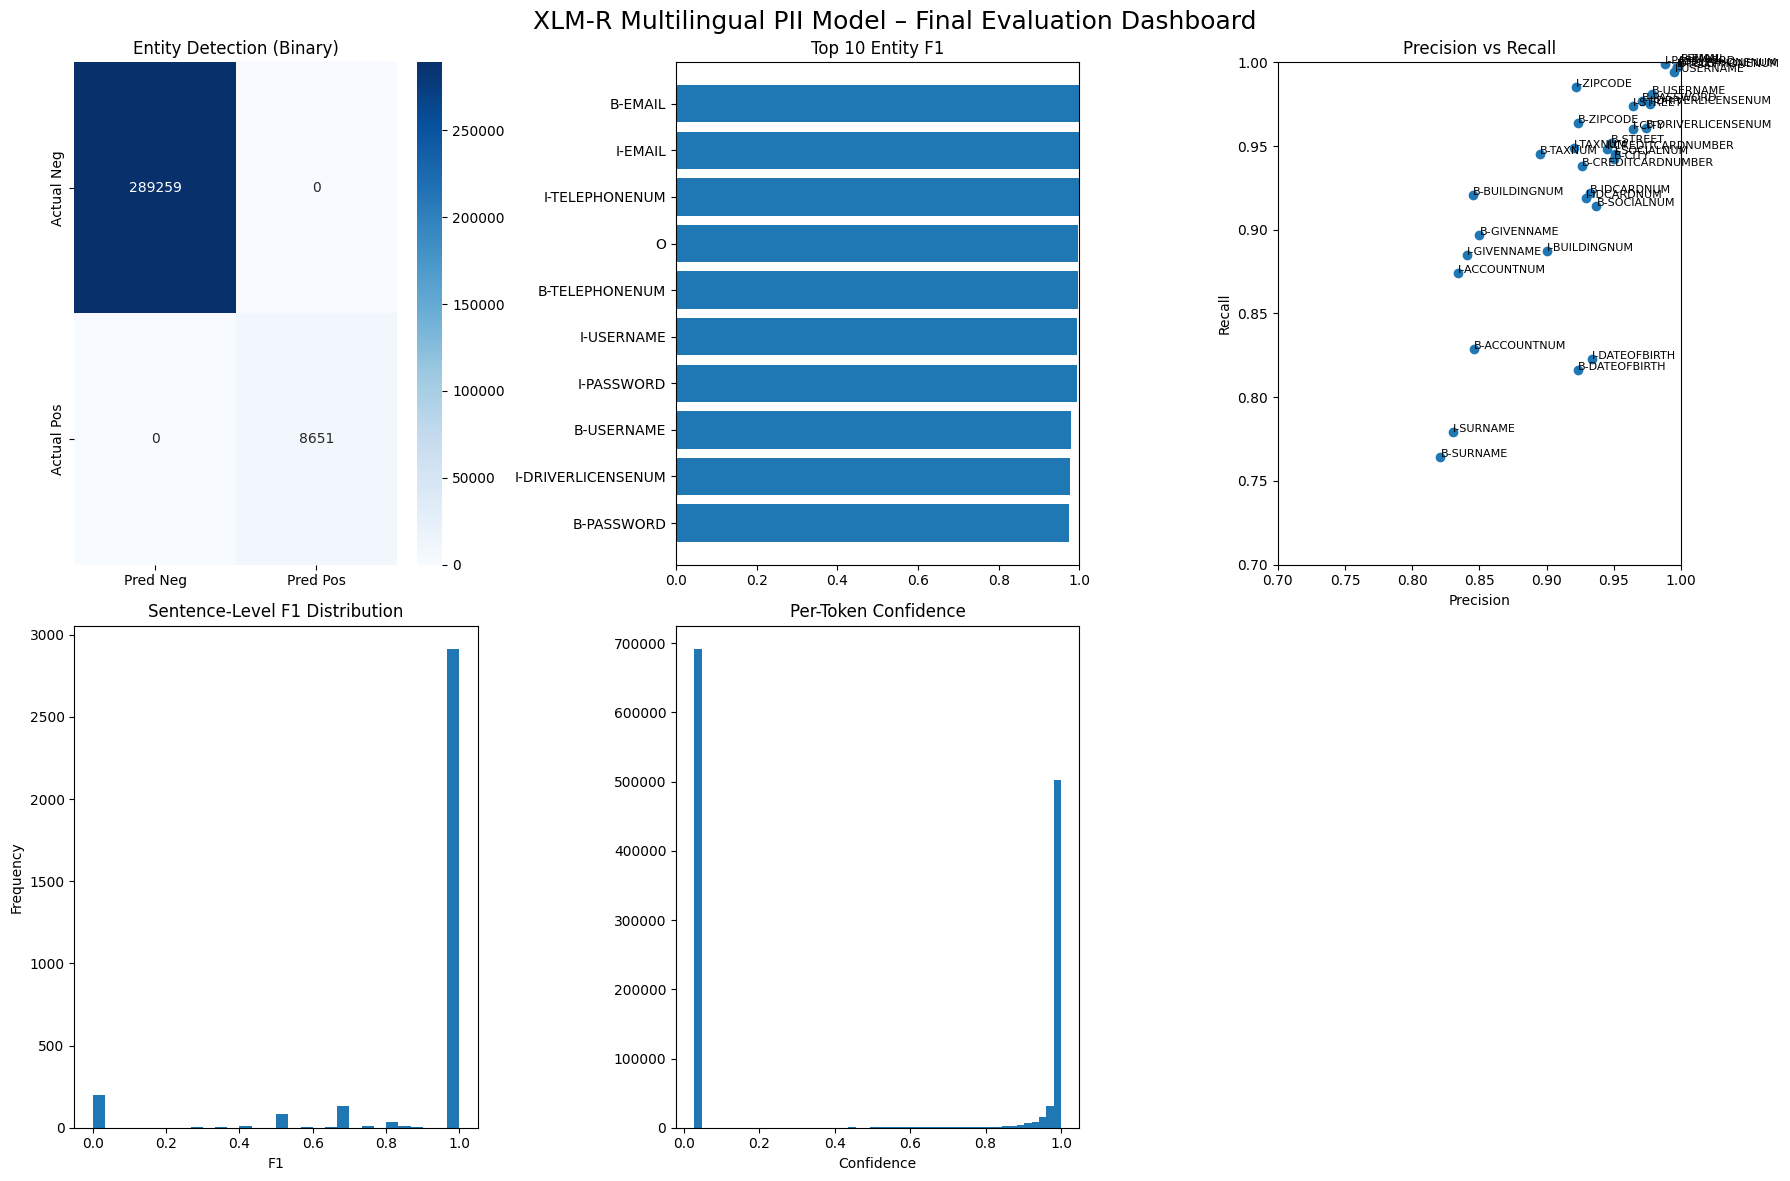

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

fig = plt.figure(figsize=(18,12))

# ==============================
# 1️⃣ Global Binary Confusion Matrix
# ==============================
ax1 = plt.subplot(2,3,1)

cm_binary = confusion_matrix(binary_true, binary_pred)

sns.heatmap(
    cm_binary,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Neg", "Pred Pos"],
    yticklabels=["Actual Neg", "Actual Pos"],
    ax=ax1
)

ax1.set_title("Entity Detection (Binary)")

# ==============================
# 2️⃣ Per-Label F1 (Top 10)
# ==============================
ax2 = plt.subplot(2,3,2)

top10 = df_errors.sort_values("F1", ascending=False).head(10)

ax2.barh(top10["Label"], top10["F1"])
ax2.set_xlim(0,1)
ax2.set_title("Top 10 Entity F1")
ax2.invert_yaxis()

# ==============================
# 3️⃣ Precision vs Recall Scatter
# ==============================
ax3 = plt.subplot(2,3,3)

ax3.scatter(df_errors["Precision"], df_errors["Recall"])

for i, row in df_errors.iterrows():
    ax3.annotate(row["Label"], (row["Precision"], row["Recall"]), fontsize=8)

ax3.set_xlim(0.7,1)
ax3.set_ylim(0.7,1)
ax3.set_xlabel("Precision")
ax3.set_ylabel("Recall")
ax3.set_title("Precision vs Recall")

# ==============================
# 4️⃣ Sentence-Level F1 Distribution
# ==============================
ax4 = plt.subplot(2,3,4)

ax4.hist(sentence_f1_scores, bins=30)
ax4.set_title("Sentence-Level F1 Distribution")
ax4.set_xlabel("F1")
ax4.set_ylabel("Frequency")

# ==============================
# 5️⃣ Confidence Distribution
# ==============================
ax5 = plt.subplot(2,3,5)

max_probs = probs.max(axis=-1).flatten()

ax5.hist(max_probs, bins=50)
ax5.set_title("Per-Token Confidence")
ax5.set_xlabel("Confidence")
plt.suptitle("XLM-R Multilingual PII Model – Final Evaluation Dashboard", fontsize=18)
plt.tight_layout()
plt.show()